#**View all 360 degree view of pandaset with pointcloud and bounding boxes**


In [3]:
import pandas as pd
import gzip
import pickle

# Example: load one LiDAR frame
with gzip.open("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/002/lidar/00.pkl.gz", "rb") as f:
    lidar_frame = pickle.load(f)

print(lidar_frame.head())

                x           y         z     i             t  d
index                                                         
0      -75.131138  -79.331690  3.511804   7.0  1.557540e+09  0
1     -112.588306 -118.666002  1.423499  31.0  1.557540e+09  0
2      -42.085902  -44.384891  0.593491   7.0  1.557540e+09  0
3      -27.329435  -28.795053 -0.403781   0.0  1.557540e+09  0
4       -6.196208   -6.621082  1.130009   3.0  1.557540e+09  0


In [4]:
import glob
import os

# Path to LiDAR frames of one sequence
lidar_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/002/lidar/"
files = sorted(glob.glob(os.path.join(lidar_path, "*.pkl.gz")))

# Load first 5 frames as example
frames = []
for i, file in enumerate(files[:5]):
    with gzip.open(file, "rb") as f:
        df = pickle.load(f)
        df["f"] = i   # frame index
        frames.append(df)

# Concatenate
all_points = pd.concat(frames)
print(all_points.head())

                x           y         z     i             t  d  f
index                                                            
0      -75.131138  -79.331690  3.511804   7.0  1.557540e+09  0  0
1     -112.588306 -118.666002  1.423499  31.0  1.557540e+09  0  0
2      -42.085902  -44.384891  0.593491   7.0  1.557540e+09  0  0
3      -27.329435  -28.795053 -0.403781   0.0  1.557540e+09  0  0
4       -6.196208   -6.621082  1.130009   3.0  1.557540e+09  0  0


In [6]:
# Load cuboids file for the sequence
cuboids_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/002/annotations/cuboids/00.pkl.gz"

with gzip.open(cuboids_file, "rb") as f:
    cuboids_df = pickle.load(f)

print(cuboids_df.head())


                                   uuid label       yaw  stationary  \
0  e83d78e4-5b11-4ad5-ac71-917b5cd19c94   Car -0.840044        True   
1  b113987c-bde4-43b3-b7f2-8a9a80318ae2   Car  2.352911        True   
2  47a397d6-9f2f-4e3b-9316-00ad60320f6d   Car  2.387817        True   
3  92b61b3d-8f2f-4205-921b-fdc047ab86e2   Car -0.787685        True   
4  895e6a77-1506-4f55-a977-baf5f86840e1   Car  2.405271        True   

   camera_used  position.x  position.y  position.z  dimensions.x  \
0            2       7.361       2.630       0.487         1.888   
1            5     -12.659       6.353       0.361         1.837   
2            4     -41.504     -22.578       0.393         1.930   
3            1      11.697       7.260       0.548         2.099   
4            4     -51.568     -32.920       0.486         1.967   

   dimensions.y  dimensions.z attributes.object_motion cuboids.sibling_id  \
0         4.747         1.761                   Parked                  -   
1         

In [7]:
import numpy as np
from mayavi import mlab

# Normalize frame index for coloring
all_points["f"] = (all_points["f"] - all_points["f"].min()) / (all_points["f"].max() - all_points["f"].min())

# Convert to numpy
pts = all_points[["x", "y", "z"]].to_numpy()
colors = all_points["f"].to_numpy()

# Plot
mlab.figure("Concatenated LiDAR", bgcolor=(0,0,0), size=(1000,800))
mlab.points3d(pts[:,0], pts[:,1], pts[:,2],
              colors,
              mode="point", colormap="spectral")

mlab.show()

In [8]:
import numpy as np

def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corner offsets
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotation (yaw around z-axis)
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])
    return corners


In [9]:
from mayavi import mlab

def draw_cuboid(corners, color=(1,0,0)):
    edges = [
        (0,1),(1,2),(2,3),(3,0),  # bottom
        (4,5),(5,6),(6,7),(7,4),  # top
        (0,4),(1,5),(2,6),(3,7)   # verticals
    ]
    for i,j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color, tube_radius=None, line_width=1.0
        )


In [10]:
mlab.figure("LiDAR + Cuboids", bgcolor=(0,0,0), size=(1000,800))

# Draw LiDAR points
mlab.points3d(pts[:,0], pts[:,1], pts[:,2],
              colors, mode="point", colormap="spectral")

# Draw cuboids
for _, cuboid in cuboids_df.iterrows():
    corners = get_cuboid_corners(cuboid)
    draw_cuboid(corners, color=(1,0,0))  # red boxes

mlab.show()


#**finished**

In [11]:
from pandaset import DataSet
import numpy as np
from mayavi import mlab

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")

seq = dataset["002"]    
seq.load_lidar()
seq.load_cuboids()
seq.load()   # <-- this loads everything, including cameras

# -----------------------------
# Access cameras
# -----------------------------
print("Available cameras:", seq.camera.keys())
camera = seq.camera["front_camera"]

# -----------------------------
# Get LiDAR + cuboids
# -----------------------------
frame_idx = 0
lidar_df = seq.lidar[frame_idx]
cuboids_df = seq.cuboids[frame_idx]

# Quick filter: keep only front-ish lidar points
lidar_front = lidar_df[
    (lidar_df["x"] > 0) & 
    (np.abs(lidar_df["y"]) < 40) &
    (lidar_df["x"] < 80)
]

# -----------------------------
# Plot in Mayavi
# -----------------------------
mlab.figure(bgcolor=(0, 0, 0), size=(1000, 800))
mlab.points3d(lidar_front["x"], lidar_front["y"], lidar_front["z"],
              lidar_front["z"], mode="point", colormap="spectral")

def draw_cuboid(cuboid, color=(1,0,0)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i,j in edges:
        mlab.plot3d([corners[i,0], corners[j,0]],
                    [corners[i,1], corners[j,1]],
                    [corners[i,2], corners[j,2]],
                    color=color, tube_radius=None, line_width=1.0)

for _, cub in cuboids_df.iterrows():
    draw_cuboid(cub, color=(1,0,0))

mlab.show()


Available cameras: dict_keys(['left_camera', 'back_camera', 'right_camera', 'front_left_camera', 'front_camera', 'front_right_camera'])


#**overlay 3D bounding boxes on Image and pointcloud**

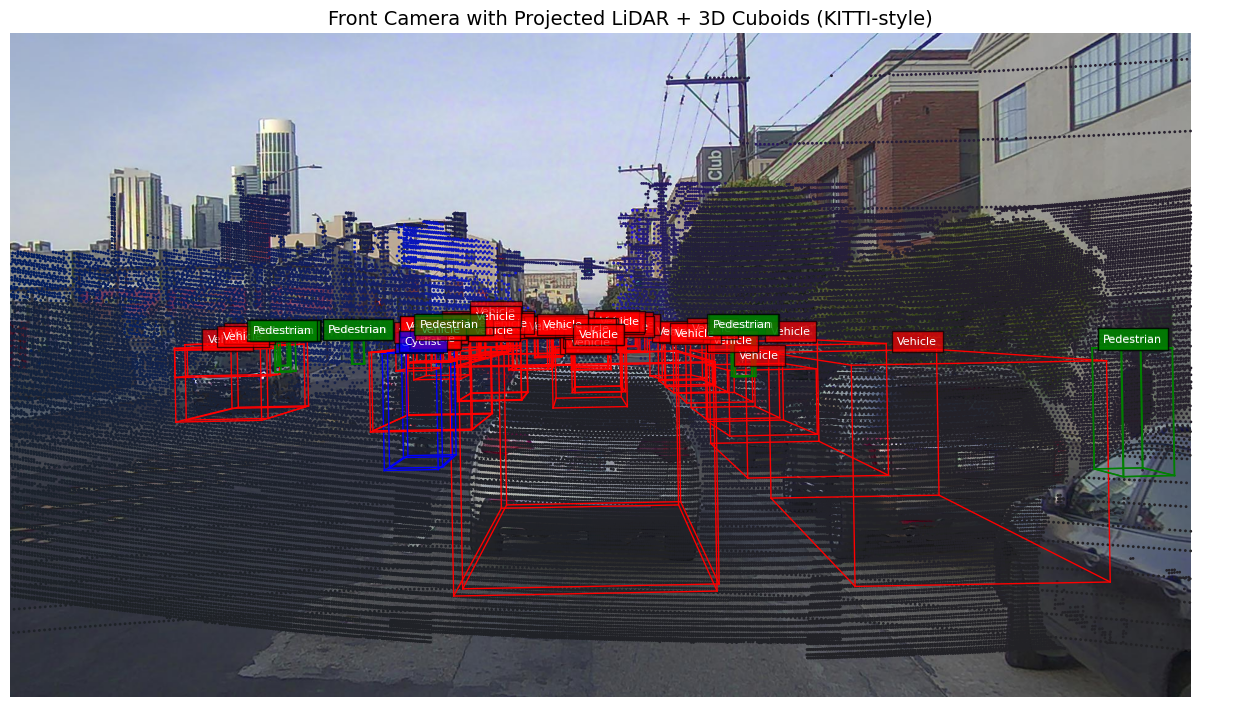

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pandaset import DataSet, geometry

# ======================================================
# Load Pandaset sequence
# ======================================================
# ⚠️ Change this path to your Pandaset folder
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")

# Pick a sequence (from your available list e.g., '002')
seq = dataset["002"]
seq.load_lidar()
seq.load_cuboids()
front_cam = seq.camera["front_camera"]
front_cam.load()

# ======================================================
# Pick a frame
# ======================================================
frame_idx = 0
lidar_points = seq.lidar[frame_idx][["x", "y", "z"]].to_numpy()  # (N,3)
cuboids = seq.cuboids[frame_idx]                                 # bounding boxes DataFrame
img = np.array(front_cam[frame_idx])                             # front camera image

# ======================================================
# Project LiDAR to camera
# ======================================================
# NOTE: filter_outliers=True already drops invalid points
projected, depths, mask = geometry.projection(
    lidar_points,
    front_cam[frame_idx],         # camera image
    front_cam.poses[frame_idx],   # camera pose
    front_cam.intrinsics,         # intrinsics
    filter_outliers=True
)

# ======================================================
# Function: cuboid corners
# ======================================================
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corner offsets
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotate around Z (yaw)
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T
    corners += np.array([x, y, z])
    return corners

# Map Pandaset labels to KITTI-style categories
def simplify_label(label):
    if "Car" in label or "Truck" in label or "Van" in label or "Bus" in label:
        return "Vehicle"
    elif "Pedestrian" in label:
        return "Pedestrian"
    elif "Cyclist" in label or "Bicycle" in label or "Motorcycle" in label:
        return "Cyclist"
    else:
        return None  # ignore others

# Colors per class
class_colors = {
    "Vehicle": "red",
    "Pedestrian": "green",
    "Cyclist": "blue"
}

# ======================================================
# Plot
# ======================================================
plt.figure(figsize=(16, 9))
plt.imshow(img)

# Normalize depth values into [0,1] for colormap
depths_normalized = (depths - depths.min()) / (depths.max() - depths.min())
plt.scatter(projected[:, 0], projected[:, 1], c=depths_normalized, cmap="jet", s=1)

# Draw cuboids
edges = [
    (0,1),(1,2),(2,3),(3,0),  # bottom
    (4,5),(5,6),(6,7),(7,4),  # top
    (0,4),(1,5),(2,6),(3,7)   # verticals
]

for _, cub in cuboids.iterrows():
    category = simplify_label(cub["label"])
    if category is None:
        continue

    color = class_colors[category]
    corners = get_cuboid_corners(cub)

    # Project cuboid corners to 2D
    proj_corners, _, _ = geometry.projection(
        corners,
        front_cam[frame_idx],
        front_cam.poses[frame_idx],
        front_cam.intrinsics,
        filter_outliers=True
    )

    if proj_corners.shape[0] != 8:
        continue

    # Draw edges
    for i, j in edges:
        plt.plot([proj_corners[i,0], proj_corners[j,0]],
                 [proj_corners[i,1], proj_corners[j,1]],
                 color=color, linewidth=1)

    # Label text
    cx, cy = np.mean(proj_corners[:,0]), np.min(proj_corners[:,1]) - 5
    plt.text(cx, cy, category, color="white", fontsize=8,
             ha="center", va="bottom", bbox=dict(facecolor=color, alpha=0.7))

plt.axis("off")
plt.title("Front Camera with Projected LiDAR + 3D Cuboids (KITTI-style)", fontsize=14)
plt.show()



🧾 Object Counts in Frame 0
Vehicle   : 84
Pedestrian: 7
Cyclist   : 1


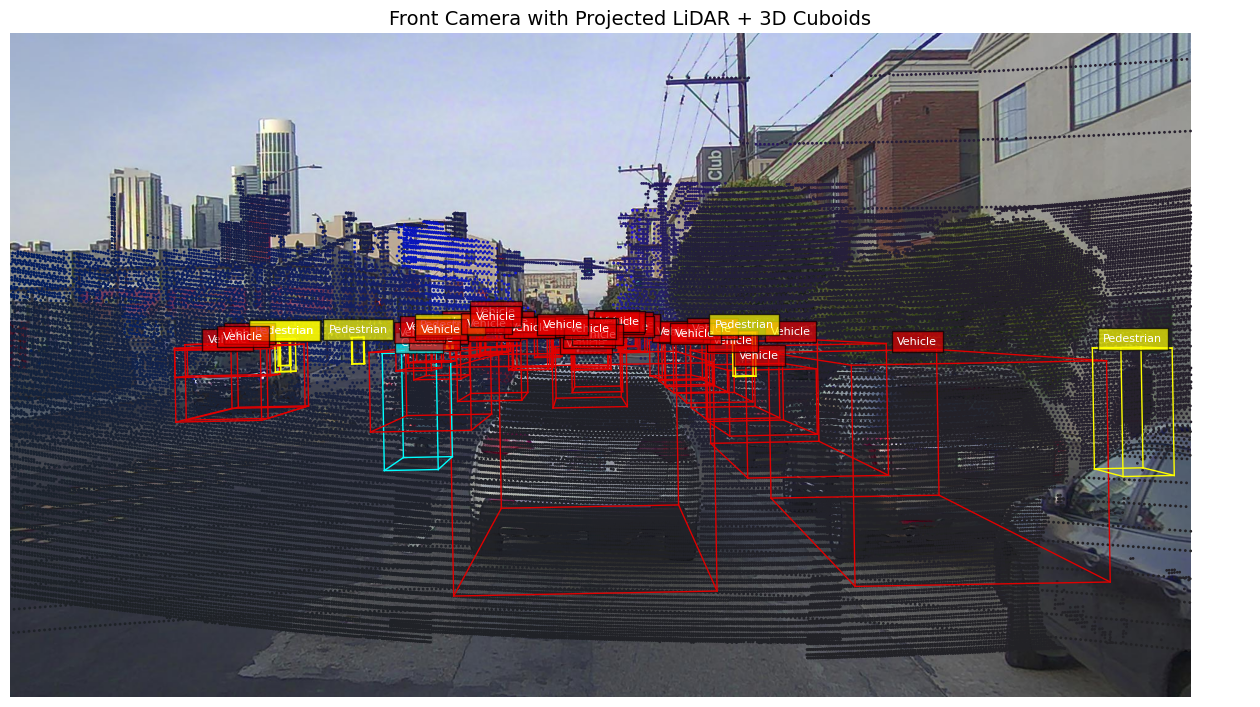

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pandaset import DataSet, geometry

# ======================================================
# Load Pandaset sequence
# ======================================================
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar()
seq.load_cuboids()
front_cam = seq.camera["front_camera"]
front_cam.load()

# ======================================================
# Pick a frame
# ======================================================
frame_idx = 0
lidar_points = seq.lidar[frame_idx][["x", "y", "z"]].to_numpy()
cuboids = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])

# ======================================================
# Project LiDAR to camera
# ======================================================
projected, depths, mask = geometry.projection(
    lidar_points,
    front_cam[frame_idx],
    front_cam.poses[frame_idx],
    front_cam.intrinsics,
    filter_outliers=True
)

# ======================================================
# Function: get cuboid corners
# ======================================================
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T
    corners += np.array([x, y, z])
    return corners

# ======================================================
# Label simplification
# ======================================================
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Pedestrian"
    elif label in ["Bicycle", "Motorcycle"]:
        return "Cyclist"
    else:
        return None

# ======================================================
# Remove near-duplicate cuboids
# ======================================================
def remove_duplicate_cuboids(cuboids_df, position_thresh=0.5):
    filtered = []
    seen = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue
        pos = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
        is_duplicate = False

        for other_pos, other_label in seen:
            if other_label == label and np.linalg.norm(pos - other_pos) < position_thresh:
                is_duplicate = True
                break

        if not is_duplicate:
            filtered.append(cub)
            seen.append((pos, label))

    return filtered

# ======================================================
# Class colors (normalized RGB for matplotlib)
# ======================================================
class_colors = {
    "Vehicle": (225 / 255, 0, 0),            # Red
    "Pedestrian": (255 / 255, 255 / 255, 0), # Yellow
    "Cyclist": (0, 255 / 255, 255 / 255)     # Cyan
}

# ======================================================
# Plotting
# ======================================================
plt.figure(figsize=(16, 9))
plt.imshow(img)

depths_normalized = (depths - depths.min()) / (depths.max() - depths.min())
plt.scatter(projected[:, 0], projected[:, 1], c=depths_normalized, cmap="jet", s=1)

edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]

filtered_cuboids = remove_duplicate_cuboids(cuboids)

# Count per class
class_counts = {"Vehicle": 0, "Pedestrian": 0, "Cyclist": 0}

for cub in filtered_cuboids:
    category = simplify_label(cub["label"])
    if category is None:
        continue

    color = class_colors[category]
    class_counts[category] += 1
    corners = get_cuboid_corners(cub)

    proj_corners, _, _ = geometry.projection(
        corners,
        front_cam[frame_idx],
        front_cam.poses[frame_idx],
        front_cam.intrinsics,
        filter_outliers=True
    )

    if proj_corners.shape[0] != 8:
        continue

    for i, j in edges:
        plt.plot([proj_corners[i,0], proj_corners[j,0]],
                 [proj_corners[i,1], proj_corners[j,1]],
                 color=color, linewidth=1)

    cx, cy = np.mean(proj_corners[:,0]), np.min(proj_corners[:,1]) - 5
    plt.text(cx, cy, category, color="white", fontsize=8,
             ha="center", va="bottom", bbox=dict(facecolor=color, alpha=0.7))

plt.axis("off")
plt.title("Front Camera with Projected LiDAR + 3D Cuboids", fontsize=14)

# Display class count in console
print("\n🧾 Object Counts in Frame", frame_idx)
for cls, count in class_counts.items():
    print(f"{cls:10s}: {count}")

plt.show()


#**view 3d bouding boxes**

In [14]:
import numpy as np
from mayavi import mlab
from pandaset import DataSet

# ======================================================
# Load Pandaset
# ======================================================
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar()
seq.load_cuboids()

# Pick a frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx][["x", "y", "z"]].to_numpy()
cuboids = seq.cuboids[frame_idx]

# ======================================================
# Define cuboid corners
# ======================================================
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corner offsets
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotation around z
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T
    corners += np.array([x, y, z])
    return corners

# ======================================================
# Simplify labels (KITTI style)
# ======================================================
def simplify_label(label):
    if "Car" in label or "Truck" in label or "Van" in label or "Bus" in label:
        return "Vehicle"
    elif "Pedestrian" in label:
        return "Pedestrian"
    elif "Cyclist" in label or "Bicycle" in label or "Motorcycle" in label:
        return "Cyclist"
    else:
        return None

class_colors = {
    "Vehicle": (1, 0, 0),   # red
    "Pedestrian": (0, 1, 0),# green
    "Cyclist": (0, 0, 1)    # blue
}

# ======================================================
# Mayavi visualization
# ======================================================
mlab.figure("LiDAR + 3D Cuboids", bgcolor=(0,0,0), size=(1280,720))

# Plot lidar points
mlab.points3d(
    lidar_points[:,0],
    lidar_points[:,1],
    lidar_points[:,2],
    mode="point",
    colormap="spectral",
    scale_factor=1.0,
)

# Draw cuboids
edges = [
    (0,1),(1,2),(2,3),(3,0),  # bottom
    (4,5),(5,6),(6,7),(7,4),  # top
    (0,4),(1,5),(2,6),(3,7)   # verticals
]

for _, cub in cuboids.iterrows():
    category = simplify_label(cub["label"])
    if category is None:
        continue
    color = class_colors[category]
    corners = get_cuboid_corners(cub)

    for i,j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1.0
        )

mlab.show()


In [ ]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet

# -----------------------------
# Load Pandaset sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids()

# Pick a frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].to_numpy()[:, :3]   # (x,y,z)
cuboids = seq.cuboids[frame_idx]

# -----------------------------
# Filter to FRONT camera field of view
# -----------------------------
fov_mask = (lidar_points[:, 0] > 0) & (np.abs(lidar_points[:, 1]) < 25) & (lidar_points[:, 0] < 60)
lidar_points = lidar_points[fov_mask]

# -----------------------------
# Map classes
# -----------------------------
def map_class(name):
    name = name.lower()
    if "car" in name or "truck" in name or "bus" in name or "vehicle" in name:
        return "Vehicle"
    elif "pedestrian" in name:
        return "Pedestrian"
    elif "cyclist" in name or "bicycle" in name or "motorcycle" in name:
        return "Cyclist"
    else:
        return None

cuboids["mapped_label"] = cuboids["label"].apply(map_class)
cuboids = cuboids[cuboids["mapped_label"].notna()]

# -----------------------------
# Draw cuboid with Mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1,0,0)):
    # Read values from columns
    x = cuboid["position.x"]
    y = cuboid["position.y"]
    z = cuboid["position.z"]
    dx = cuboid["dimensions.x"]
    dy = cuboid["dimensions.y"]
    dz = cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # Define local corners
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
    ])

    # Rotation about Z
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    rotated = corners @ R.T
    corners = rotated + np.array([x, y, z])

    edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]
    for i,j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color, tube_radius=None, line_width=1.0
        )

# -----------------------------
# Plot in Mayavi
# -----------------------------
mlab.figure(bgcolor=(0,0,0), size=(1600,1000))
mlab.points3d(lidar_points[:,0], lidar_points[:,1], lidar_points[:,2],
              mode="point", color=(1,1,1), scale_factor=0.05)

for _, cub in cuboids.iterrows():
    if cub["mapped_label"] == "Vehicle":
        draw_cuboid(cub, color=(1,0,0))  # red
    elif cub["mapped_label"] == "Pedestrian":
        draw_cuboid(cub, color=(0,1,0))  # green
    elif cub["mapped_label"] == "Cyclist":
        draw_cuboid(cub, color=(0,0,1))  # blue

mlab.view(azimuth=180, elevation=90, distance=60, focalpoint=(30,0,0))  # front view
mlab.show()


#**Check Pandaset classes**

In [ ]:
import os
from pandaset import DataSet
from collections import Counter

# ======================================================
# ⚠️ Set this to your local path for Pandaset
dataset_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset"
dataset = DataSet(dataset_path)

# ======================================================
# OPTION 1: List classes across ALL sequences
# ======================================================
all_labels = set()
label_counter = Counter()

# List of available sequences
sequences = dataset.sequences()
print(f"Total sequences: {len(sequences)}\n")

for seq_name in sequences:
    print(f"Processing sequence: {seq_name}")
    seq = dataset[seq_name]
    
    try:
        seq.load_cuboids()
    except Exception as e:
        print(f"Warning: Could not load cuboids for {seq_name}. Skipping.")
        continue
    
    for frame in seq.cuboids:
        if frame is not None and not frame.empty:
            unique_labels = frame["label"].unique()
            all_labels.update(unique_labels)
            label_counter.update(frame["label"].values)

# ======================================================
# Output unique class labels
# ======================================================
print("\n✅ Unique object classes in Pandaset (from all sequences):\n")
for label in sorted(all_labels):
    print(f"- {label}")

# ======================================================
# Output class frequency (optional)
# ======================================================
print("\n📊 Frequency of each class label (object count across dataset):\n")
for label, count in label_counter.most_common():
    print(f"{label:30s}: {count}")


Total sequences: 40

Processing sequence: 016
Processing sequence: 039
Processing sequence: 030
Processing sequence: 018
Processing sequence: 023
Processing sequence: 028
Processing sequence: 003
Processing sequence: 011
Processing sequence: 017
Processing sequence: 041
Processing sequence: 019
Processing sequence: 034
Processing sequence: 002
Processing sequence: 024
Processing sequence: 043
Processing sequence: 005
Processing sequence: 044
Processing sequence: 006
Processing sequence: 040
Processing sequence: 029
Processing sequence: 035
Processing sequence: 013
Processing sequence: 014
Processing sequence: 001
Processing sequence: 004
Processing sequence: 027
Processing sequence: 037
Processing sequence: save
Processing sequence: 038
Processing sequence: 042
Processing sequence: 008
Processing sequence: 015
Processing sequence: 047
Processing sequence: 032
Processing sequence: 045
Processing sequence: 033
Processing sequence: 021
Processing sequence: 046
Processing sequence: 012
Pro

#**Perfect FORWAD VIEW WITH BOUNDING BOXES AND RANGE**

In [15]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map (normalized RGB for mayavi)
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),      # red
    "Pedestrian": (1, 1, 0),         # yellow
    "Cyclist": (0, 1, 1)             # cyan
}

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Pedestrian"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyclist"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids
# -----------------------------
def remove_duplicate_cuboids(cuboids_df, threshold=0.5):
    filtered = []
    seen = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue
        pos = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
        duplicate_found = False

        for other_pos, other_label in seen:
            if other_label == label and np.linalg.norm(pos - other_pos) < threshold:
                duplicate_found = True
                break

        if not duplicate_found:
            filtered.append((cub, label))
            seen.append((pos, label))

    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # corners
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1
        )

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("LiDAR + 3D Cuboids", bgcolor=(0,0,0), size=(w,h))

mlab.points3d(
    lidar_front[:,0],
    lidar_front[:,1],
    lidar_front[:,2],
    mode="point",
    color=(1,1,1),
    scale_factor=1
)

# Filter and deduplicate cuboids
min_dist = 0
max_dist = 120
filtered_cuboids = []

for cub, label in remove_duplicate_cuboids(cuboids_df):
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist:
        continue

    # Check FOV
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if inside.any():
        if label in class_colors:
            draw_cuboid(cub, color=class_colors[label])

mlab.show()


#**3D BOXES WITH CLASSES----NAMES**

In [16]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map (normalized RGB for mayavi)
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),      # red
    "Ped": (1, 1, 0),         # yellow
    "Cyc": (0, 1, 1)             # cyan
}

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Ped"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyc"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids (3D center distance)
# -----------------------------
def remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0):
    filtered = []
    seen_centers = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue

        center = np.array([
            cub["position.x"],
            cub["position.y"],
            cub["position.z"]
        ])

        is_duplicate = False
        for other_center, other_label in seen_centers:
            if label == other_label and np.linalg.norm(center - other_center) < threshold:
                is_duplicate = True
                break

        if not is_duplicate:
            filtered.append((cub, label))
            seen_centers.append((center, label))

    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1
        )

# -----------------------------
# Draw label text in 3D
# -----------------------------
def draw_label(text, position, color=(1, 1, 1)):
    x, y, z = position
    mlab.text3d(x, y, z + 1.0, text, color=color, scale=0.8)

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("LiDAR + 3D Cuboids with Labels", bgcolor=(0,0,0), size=(w, h))

mlab.points3d(
    lidar_front[:,0],
    lidar_front[:,1],
    lidar_front[:,2],
    mode="point",
    color=(1,1,1),
    scale_factor=1
)

# Filter and deduplicate cuboids
min_dist = 0
max_dist = 120

filtered_cuboids = remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0)

for cub, label in filtered_cuboids:
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist:
        continue

    # Check FOV
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if inside.any() and label in class_colors:
        draw_cuboid(cub, color=class_colors[label])
        draw_label(label, position=center, color=class_colors[label])

mlab.show()


#**Boxes with class numbers**

In [17]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map (normalized RGB for mayavi)
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),  # red
    "Ped": (1, 1, 0),            # yellow
    "Cyc": (0, 1, 1)             # cyan
}

# -----------------------------
# Class ID map (string labels to numeric IDs)
# -----------------------------
class_ids = {
    "Vehicle": "0",
    "Ped": "1",
    "Cyc": "2"
}

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Ped"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyc"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids (3D center distance)
# -----------------------------
def remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0):
    filtered = []
    seen_centers = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue

        center = np.array([
            cub["position.x"],
            cub["position.y"],
            cub["position.z"]
        ])

        is_duplicate = False
        for other_center, other_label in seen_centers:
            if label == other_label and np.linalg.norm(center - other_center) < threshold:
                is_duplicate = True
                break

        if not is_duplicate:
            filtered.append((cub, label))
            seen_centers.append((center, label))

    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1
        )

# -----------------------------
# Draw numeric label in 3D
# -----------------------------
def draw_numeric_label(label, position, color=(1, 1, 1)):
    x, y, z = position
    text = class_ids.get(label, "?")  # Use "?" if label is not in class_ids
    mlab.text3d(x, y, z + 1.0, text, color=color, scale=0.8)

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("LiDAR + 3D Cuboids with Numeric Labels", bgcolor=(0,0,0), size=(w, h))

mlab.points3d(
    lidar_front[:,0],
    lidar_front[:,1],
    lidar_front[:,2],
    mode="point",
    color=(1,1,1),
    scale_factor=1
)

# Filter and deduplicate cuboids
min_dist = 0
max_dist = 120
filtered_cuboids = remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0)

for cub, label in filtered_cuboids:
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist:
        continue

    # Check FOV
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if inside.any() and label in class_colors:
        draw_cuboid(cub, color=class_colors[label])
        draw_numeric_label(label, position=center, color=class_colors[label])

mlab.show()


#**Ground + Pred**

In [5]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["044"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),  # red
    "Ped": (1, 1, 0),            # yellow
    "Cyc": (0, 1, 1)             # cyan
}
class_ids = {
    "Vehicle": "0",
    "Ped": "1",
    "Cyc": "2"
}
ground_truth_color = (0, 0, 1)  # blue

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Ped"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyc"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids
# -----------------------------
def remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0):
    filtered = []
    seen_centers = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue

        center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
        is_duplicate = False
        for other_center, other_label in seen_centers:
            if label == other_label and np.linalg.norm(center - other_center) < threshold:
                is_duplicate = True
                break
        if not is_duplicate:
            filtered.append((cub, label))
            seen_centers.append((center, label))

    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=2
        )

# -----------------------------
# Draw label text
# -----------------------------
def draw_numeric_label(label, position, color=(1, 1, 1)):
    x, y, z = position
    text = class_ids.get(label, "?")
    mlab.text3d(x, y, z + 1.0, text, color=color, scale=0.8)

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("GT vs Prediction", bgcolor=(1,1,1), size=(w, h))
mlab.points3d(
    lidar_front[:,0],
    lidar_front[:,1],
    lidar_front[:,2],
    mode="point",
    color=(0,0,0),
    scale_factor=1
)

filtered_cuboids = remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0)
min_dist = 0
max_dist = 120

for cub, label in filtered_cuboids:
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist or label not in class_colors:
        continue

    # Check if visible in camera
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if not inside.any():
        continue

    # Draw ground truth
    draw_cuboid(cub, color=ground_truth_color)
    draw_numeric_label(label, center, ground_truth_color)

    # Create fake prediction by offsetting GT position slightly
    pred_cub = cub.copy()
    pred_cub["position.x"] += np.random.uniform(-0.5, 0.5)
    pred_cub["position.y"] += np.random.uniform(-0.5, 0.5)
    pred_cub["position.z"] += np.random.uniform(-0.2, 0.2)

    draw_cuboid(pred_cub, color=class_colors[label])
    pred_center = np.array([pred_cub["position.x"], pred_cub["position.y"], pred_cub["position.z"]])
    draw_numeric_label(label, pred_center, class_colors[label])

mlab.show()


#**close ground+ pred**

In [4]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["044"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),  # red
    "Ped": (1, 1, 0),            # yellow
    "Cyc": (0, 1, 1)             # cyan
}
class_ids = {"Vehicle": "0", "Ped": "1", "Cyc": "2"}
ground_truth_color = (0, 0, 1)  # blue

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", 
                 "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Ped"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyc"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids
# -----------------------------
def remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0):
    filtered, seen_centers = [], []
    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue
        center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
        if any(label == ol and np.linalg.norm(center - oc) < threshold 
               for oc, ol in seen_centers):
            continue
        filtered.append((cub, label))
        seen_centers.append((center, label))
    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                  [np.sin(yaw),  np.cos(yaw), 0],
                  [0, 0, 1]])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d([corners[i,0], corners[j,0]],
                    [corners[i,1], corners[j,1]],
                    [corners[i,2], corners[j,2]],
                    color=color, tube_radius=None, line_width=2)

# -----------------------------
# Draw label text
# -----------------------------
def draw_numeric_label(label, position, color=(1, 1, 1)):
    x, y, z = position
    text = class_ids.get(label, "?")
    mlab.text3d(x, y, z + 1.0, text, color=color, scale=0.8)

# -----------------------------
# Add small noise for fake predictions
# -----------------------------
def make_noisy_prediction(cub):
    pred_cub = cub.copy()
    # Position noise (smaller than before, ~15 cm)
    pred_cub["position.x"] += np.random.uniform(-0.07, 0.07)
    pred_cub["position.y"] += np.random.uniform(-0.07, 0.07)
    pred_cub["position.z"] += np.random.uniform(-0.05, 0.05)
    # Size jitter (~5%)
    pred_cub["dimensions.x"] *= np.random.uniform(0.95, 1.05)
    pred_cub["dimensions.y"] *= np.random.uniform(0.95, 1.05)
    pred_cub["dimensions.z"] *= np.random.uniform(0.95, 1.05)
    # Yaw jitter (~3 degrees)
    pred_cub["yaw"] += np.random.uniform(-0.05, 0.05)
    return pred_cub

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("GT vs Prediction", bgcolor=(1,1,1), size=(w, h))
mlab.points3d(lidar_front[:,0], lidar_front[:,1], lidar_front[:,2],
              mode="point", color=(0,0,0), scale_factor=1)

filtered_cuboids = remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0)

for cub, label in filtered_cuboids:
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < 0 or dist > 120 or label not in class_colors:
        continue

    # Project corners to check if visible in camera
    dx, dy, dz, yaw = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"], cub["yaw"]
    corners = np.array([[ dx/2,  dy/2, -dz/2], [-dx/2,  dy/2, -dz/2],
                        [-dx/2, -dy/2, -dz/2], [ dx/2, -dy/2, -dz/2],
                        [ dx/2,  dy/2,  dz/2], [-dx/2,  dy/2,  dz/2],
                        [-dx/2, -dy/2,  dz/2], [ dx/2, -dy/2,  dz/2]])
    R = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                  [np.sin(yaw),  np.cos(yaw), 0],
                  [0, 0, 1]])
    corners = corners @ R.T + center
    _, _, inside = geometry.projection(lidar_points=corners,
                                       camera_data=front_cam[frame_idx],
                                       camera_pose=front_cam.poses[frame_idx],
                                       camera_intrinsics=front_cam.intrinsics,
                                       filter_outliers=True)
    if not inside.any():
        continue

    # Draw GT
    draw_cuboid(cub, color=ground_truth_color)
    draw_numeric_label(label, center, ground_truth_color)

    # Draw fake prediction (slightly noisy GT)
    pred_cub = make_noisy_prediction(cub)
    draw_cuboid(pred_cub, color=class_colors[label])
    pred_center = np.array([pred_cub["position.x"], pred_cub["position.y"], pred_cub["position.z"]])
    draw_numeric_label(label, pred_center, class_colors[label])

mlab.show()


#**Teacher---predict--only80m**

In [ ]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),  # red
    "Ped": (1, 1, 0),            # yellow
    "Cyc": (0, 1, 1)             # cyan
}
class_ids = {
    "Vehicle": "0",
    "Ped": "1",
    "Cyc": "2"
}
ground_truth_color = (0, 0, 1)  # blue

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Ped"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyc"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids
# -----------------------------
def remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0):
    filtered = []
    seen_centers = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue

        center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
        is_duplicate = False
        for other_center, other_label in seen_centers:
            if label == other_label and np.linalg.norm(center - other_center) < threshold:
                is_duplicate = True
                break
        if not is_duplicate:
            filtered.append((cub, label))
            seen_centers.append((center, label))

    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1
        )

# -----------------------------
# Draw label text
# -----------------------------
def draw_numeric_label(label, position, color=(1, 1, 1)):
    x, y, z = position
    text = class_ids.get(label, "?")
    mlab.text3d(x, y, z + 1.0, text, color=color, scale=0.8)

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("GT vs Prediction (Teacher skips >80m)", bgcolor=(0,0,0), size=(w, h))
mlab.points3d(
    lidar_front[:,0],
    lidar_front[:,1],
    lidar_front[:,2],
    mode="point",
    color=(1,1,1),
    scale_factor=1
)

filtered_cuboids = remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0)
min_dist = 0
max_dist = 120
teacher_max_dist = 80  # Teacher will only "predict" boxes within 80m

for cub, label in filtered_cuboids:
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist or label not in class_colors:
        continue

    # Check if visible in camera
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if not inside.any():
        continue

    # Draw ground truth
    draw_cuboid(cub, color=ground_truth_color)
    draw_numeric_label(label, center, ground_truth_color)

    # Draw teacher prediction only if within 80 meters
    if dist <= teacher_max_dist:
        pred_cub = cub.copy()
        pred_cub["position.x"] += np.random.uniform(-0.5, 0.5)
        pred_cub["position.y"] += np.random.uniform(-0.5, 0.5)
        pred_cub["position.z"] += np.random.uniform(-0.2, 0.2)

        draw_cuboid(pred_cub, color=class_colors[label])
        pred_center = np.array([
            pred_cub["position.x"],
            pred_cub["position.y"],
            pred_cub["position.z"]
        ])
        draw_numeric_label(label, pred_center, class_colors[label])

mlab.show()


#**teacher predict--skipsome after 80m**

In [33]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids().load_camera()
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]
cuboids_df = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])
h, w, _ = img.shape

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)
lidar_front = lidar_points[mask]

# -----------------------------
# Class color map
# -----------------------------
class_colors = {
    "Vehicle": (225/255, 0, 0),  # red
    "Ped": (1, 1, 0),            # yellow
    "Cyc": (0, 1, 1)             # cyan
}
class_ids = {
    "Vehicle": "0",
    "Ped": "1",
    "Cyc": "2"
}
ground_truth_color = (0, 0, 1)  # blue

# -----------------------------
# Label simplification
# -----------------------------
def simplify_label(label):
    if label in ["Car", "Truck", "Van", "Bus", "Pickup Truck", "Medium-sized Truck", "Other Vehicle - Construction Vehicle"]:
        return "Vehicle"
    elif label in ["Pedestrian", "Pedestrian with Object"]:
        return "Ped"
    elif label in ["Bicycle", "Motorcycle", "Cyclist"]:
        return "Cyc"
    else:
        return None

# -----------------------------
# Remove duplicate cuboids
# -----------------------------
def remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0):
    filtered = []
    seen_centers = []

    for _, cub in cuboids_df.iterrows():
        label = simplify_label(cub["label"])
        if label is None:
            continue

        center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
        is_duplicate = False
        for other_center, other_label in seen_centers:
            if label == other_label and np.linalg.norm(center - other_center) < threshold:
                is_duplicate = True
                break
        if not is_duplicate:
            filtered.append((cub, label))
            seen_centers.append((center, label))

    return filtered

# -----------------------------
# Draw cuboid in mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1, 1, 1)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1
        )

# -----------------------------
# Draw label text
# -----------------------------
def draw_numeric_label(label, position, color=(1, 1, 1)):
    x, y, z = position
    text = class_ids.get(label, "?")
    mlab.text3d(x, y, z + 1.0, text, color=color, scale=0.8)

# -----------------------------
# Visualization
# -----------------------------
mlab.figure("GT vs Prediction (Teacher skips some >80m)", bgcolor=(1,1,1), size=(w, h))
mlab.points3d(
    lidar_front[:,0],
    lidar_front[:,1],
    lidar_front[:,2],
    mode="point",
    color=(0,0,0),
    scale_factor=2
)

filtered_cuboids = remove_duplicate_cuboids_by_distance(cuboids_df, threshold=1.0)
min_dist = 0
max_dist = 120
teacher_max_dist = 80  # Teacher full prediction up to 80m

for cub, label in filtered_cuboids:
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist or label not in class_colors:
        continue

    # Check if visible in camera
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if not inside.any():
        continue

    # Draw ground truth
    draw_cuboid(cub, color=ground_truth_color)
    draw_numeric_label(label, center, ground_truth_color)

    # Decide whether teacher predicts this box
    include_teacher = True
    if dist > teacher_max_dist:
        include_teacher = np.random.rand() < 0.4  # Keep 40 percent after 80m

    if include_teacher:
        pred_cub = cub.copy()
        pred_cub["position.x"] += np.random.uniform(-0.5, 0.5)
        pred_cub["position.y"] += np.random.uniform(-0.5, 0.5)
        pred_cub["position.z"] += np.random.uniform(-0.2, 0.2)

        draw_cuboid(pred_cub, color=class_colors[label])
        pred_center = np.array([
            pred_cub["position.x"],
            pred_cub["position.y"],
            pred_cub["position.z"]
        ])
        draw_numeric_label(label, pred_center, class_colors[label])

mlab.show()


#**DATATSET DETAILS**

In [ ]:
import os

# Path to your Pandaset root directory
root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset"

def count_files_in_folder(folder, exts=None):
    """Count files in a folder with given extensions"""
    if not os.path.exists(folder):
        return 0
    files = os.listdir(folder)
    if exts:
        files = [f for f in files if f.lower().endswith(tuple(exts))]
    return len(files)

def summarize_sequence(seq_path):
    summary = {}
    
    # LiDAR frames
    lidar_path = os.path.join(seq_path, "lidar")
    summary["lidar_frames"] = count_files_in_folder(lidar_path, [".pkl"])
    
    # Annotations (cuboids)
    ann_path = os.path.join(seq_path, "annotations", "cuboids")
    summary["annotations"] = count_files_in_folder(ann_path, [".pkl"])
    
    # Cameras
    cam_path = os.path.join(seq_path, "camera")
    cameras = ["front_camera", "back_camera", "left_camera", "right_camera", 
               "front_left_camera", "front_right_camera"]
    cam_counts = {}
    for cam in cameras:
        cam_folder = os.path.join(cam_path, cam)
        cam_counts[cam] = count_files_in_folder(cam_folder, [".jpg", ".png"])
    
    summary["cameras"] = cam_counts
    return summary

# Go through all sequences (directories with digits only)
sequences = sorted([d for d in os.listdir(root) if d.isdigit()])
dataset_summary = {}

# Totals
total_lidar = 0
total_annotations = 0
total_cameras = {cam: 0 for cam in 
                 ["front_camera", "back_camera", "left_camera", "right_camera", 
                  "front_left_camera", "front_right_camera"]}

for seq in sequences:
    seq_path = os.path.join(root, seq)
    summary = summarize_sequence(seq_path)
    dataset_summary[seq] = summary
    
    # Update totals
    total_lidar += summary["lidar_frames"]
    total_annotations += summary["annotations"]
    for cam, count in summary["cameras"].items():
        total_cameras[cam] += count

# Print per-sequence results
for seq, summary in dataset_summary.items():
    print(f"\nSequence {seq}:")
    print(f"  LiDAR frames: {summary['lidar_frames']}")
    print(f"  Annotations: {summary['annotations']}")
    for cam, count in summary["cameras"].items():
        print(f"  {cam}: {count} images")

# Print totals
print("\n==== Dataset Totals ====")
print(f"Total sequences: {len(sequences)}")
print(f"Total LiDAR frames: {total_lidar}")
print(f"Total annotation frames: {total_annotations}")
print("Camera image counts:")
for cam, total in total_cameras.items():
    print(f"  {cam}: {total} images")
print(f"Total images across all cameras: {sum(total_cameras.values())}")



Sequence 001:
  LiDAR frames: 80
  Annotations: 80
  front_camera: 80 images
  back_camera: 80 images
  left_camera: 80 images
  right_camera: 80 images
  front_left_camera: 80 images
  front_right_camera: 80 images

Sequence 002:
  LiDAR frames: 80
  Annotations: 80
  front_camera: 80 images
  back_camera: 80 images
  left_camera: 80 images
  right_camera: 80 images
  front_left_camera: 80 images
  front_right_camera: 80 images

Sequence 003:
  LiDAR frames: 80
  Annotations: 80
  front_camera: 80 images
  back_camera: 80 images
  left_camera: 80 images
  right_camera: 80 images
  front_left_camera: 80 images
  front_right_camera: 80 images

Sequence 004:
  LiDAR frames: 80
  Annotations: 80
  front_camera: 80 images
  back_camera: 80 images
  left_camera: 80 images
  right_camera: 80 images
  front_left_camera: 80 images
  front_right_camera: 80 images

Sequence 005:
  LiDAR frames: 80
  Annotations: 80
  front_camera: 80 images
  back_camera: 80 images
  left_camera: 80 images
  ri

In [ ]:
import os
import pickle
import pandas as pd  # Needed because annotations are stored as DataFrames

# Path to your Pandaset root directory
root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset"

labels = set()

# Go through all sequences (001, 002, ...)
sequences = sorted([d for d in os.listdir(root) if d.isdigit()])

for seq in sequences:
    ann_path = os.path.join(root, seq, "annotations", "cuboids")
    if not os.path.exists(ann_path):
        continue

    for f in os.listdir(ann_path):
        if f.endswith(".pkl"):
            fpath = os.path.join(ann_path, f)
            try:
                with open(fpath, "rb") as fh:
                    data = pickle.load(fh)

                # Case 1: DataFrame (most common in Pandaset cuboids)
                if isinstance(data, pd.DataFrame):
                    if "label" in data.columns:
                        labels.update(data["label"].unique())

                # Case 2: list of dicts
                elif isinstance(data, list):
                    for cuboid in data:
                        if isinstance(cuboid, dict) and "label" in cuboid:
                            labels.add(cuboid["label"])

                # Case 3: dict with "cuboids" key
                elif isinstance(data, dict) and "cuboids" in data:
                    for cuboid in data["cuboids"]:
                        if isinstance(cuboid, dict) and "label" in cuboid:
                            labels.add(cuboid["label"])

            except Exception as e:
                print(f"Error reading {fpath}: {e}")

print("\n==== Annotation Labels in Pandaset ====")
for label in sorted(labels):
    print(label)



==== Annotation Labels in Pandaset ====
Animals - Other
Bicycle
Bus
Car
Cones
Construction Signs
Emergency Vehicle
Medium-sized Truck
Motorcycle
Motorized Scooter
Other Vehicle - Construction Vehicle
Other Vehicle - Pedicab
Other Vehicle - Uncommon
Pedestrian
Pedestrian with Object
Personal Mobility Device
Pickup Truck
Pylons
Road Barriers
Rolling Containers
Semi-truck
Signs
Temporary Construction Barriers
Towed Object
Train
Tram / Subway


#**VIEW SEMSEG**

In [ ]:
import os
import pickle
import json
import numpy as np
from collections import Counter

# Pick which sequence to inspect
sequence = "003"  

root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset"
seq_path = os.path.join(root, sequence, "annotations", "semseg")

# Load class mapping (ID -> class name)
classes_file = os.path.join(seq_path, "classes.json")
with open(classes_file, "r") as f:
    class_map = json.load(f)

print("Loaded", len(class_map), "semantic classes from", classes_file)

# Pick one semseg frame (e.g. 00.pkl)
frame_file = os.path.join(seq_path, "00.pkl")

with open(frame_file, "rb") as f:
    data = pickle.load(f)

print("Type of data:", type(data))

# Case 1: If it's a DataFrame
if hasattr(data, "columns"):
    if "label" in data.columns:
        labels = data["label"].values
    elif "class" in data.columns:
        labels = data["class"].values
    else:
        raise KeyError("No label column found in semseg DataFrame")

# Case 2: If it's a dict
elif isinstance(data, dict):
    labels = data.get("labels", None)
    if labels is None:
        raise KeyError("No 'labels' key found in semseg dict")

else:
    raise TypeError("Unexpected data format in semseg .pkl")

# Count class frequencies
counts = Counter(labels)

print(f"\n==== Semantic Segmentation Counts for Sequence {sequence}, Frame 00 ====")
for class_id, count in counts.items():
    class_name = class_map.get(str(class_id), f"Unknown({class_id})")
    print(f"{class_name}: {count} points")


Loaded 42 semantic classes from /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/003/annotations/semseg/classes.json
Type of data: <class 'pandas.core.frame.DataFrame'>

==== Semantic Segmentation Counts for Sequence 003, Frame 00 ====
Vegetation: 13167 points
Road: 41499 points
Bus: 3 points
Car: 23388 points
Pedestrian: 250 points
Other Static Object: 14012 points
Reflection: 849 points
Building: 75278 points
Lane Line Marking: 821 points
Other Road Marking: 216 points
Signs: 10 points
Sidewalk: 2017 points
Driveway: 80 points
Cones: 9 points
Personal Mobility Device: 26 points
Medium-sized Truck: 237 points
Pedestrian with Object: 71 points
Motorcycle: 53 points
Pickup Truck: 4080 points
Ground: 42 points


In [ ]:
import os
import pickle
import json
import numpy as np
import pandas as pd
from mayavi import mlab

# Paths (adjust your root path if needed)
root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/003"
lidar_file = os.path.join(root, "lidar", "00.pkl")
semseg_file = os.path.join(root, "annotations", "semseg", "00.pkl")
classes_file = os.path.join(root, "annotations", "semseg", "classes.json")

# Load lidar points
with open(lidar_file, "rb") as f:
    lidar = pickle.load(f)   # DataFrame
points = lidar[["x", "y", "z"]].to_numpy()

# Load semantic labels
semseg = pd.read_pickle(semseg_file)  # DataFrame with column ['class']
labels = semseg["class"].to_numpy().astype(int)

print("Points shape:", points.shape)
print("Labels shape:", labels.shape)

# Load class mapping
with open(classes_file, "r") as f:
    class_map = json.load(f)
class_map = {int(k): v for k, v in class_map.items()}
print(f"Loaded {len(class_map)} semantic classes")

# Ensure same length
assert points.shape[0] == labels.shape[0], "Mismatch between points and labels!"

# Visualize with Mayavi
mlab.figure("Pandaset Semantic Segmentation", bgcolor=(0, 0, 0), size=(1200, 800))
mlab.points3d(
    points[:, 0],
    points[:, 1],
    points[:, 2],
    labels,   # coloring by semantic class
    mode="point",
    scale_factor=1
)
mlab.colorbar(title="Class ID", orientation="vertical")
mlab.show()


Points shape: (176108, 3)
Labels shape: (176108,)
Loaded 42 semantic classes


In [ ]:
from mayavi import mlab

# Visualize point cloud with semantic labels
mlab.figure("Pandaset Semantic Segmentation", bgcolor=(0, 0, 0), size=(1200, 800))
sc = mlab.points3d(
    points[:, 0],
    points[:, 1],
    points[:, 2],
    labels,   # semantic labels
    mode="point",
    scale_factor=1
)

# Explicitly set scalar range to match label IDs
sc.module_manager.scalar_lut_manager.data_range = (labels.min(), labels.max())

# Add colorbar
cb = mlab.colorbar(object=sc, title="Class ID", orientation="vertical")
cb.scalar_bar.label_text_property.font_size = 8
cb.scalar_bar.title_text_property.font_size = 10

mlab.show()
